# Fragility-Guided Text-Prompted Brain Tumor Segmentation

## Using MedCLIP-SAMv2 Pipeline with MLFM Fragility Weighting

**Baseline**: MedCLIP-SAMv2 (BiomedCLIP + M2IB + SAM) with equal modality fusion

**Your Method**: MedCLIP-SAMv2 with MLFM fragility-based modality weighting

---

## Part 1: Clone MedCLIP-SAMv2

In [1]:
import os
from pathlib import Path

if not Path('MedCLIP-SAMv2').exists():
    !git clone https://github.com/HealthX-Lab/MedCLIP-SAMv2.git

os.chdir('MedCLIP-SAMv2')
print(f"Working directory: {os.getcwd()}")

Working directory: c:\Users\arnav\Desktop\MedBIND3D\MedBIND3D\medclipsam\MedCLIP-SAMv2


## Part 2: Install Dependencies

In [2]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install Pillow typing-extensions ttach kornia tqdm opencv-python ftfy regex scikit-image ipython matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install transformers open_clip_torch grad-cam

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
%pip install SimpleITK segment-anything

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
%pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to c:\users\arnav\appdata\local\temp\pip-req-build-xd721v2f
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\arnav\AppData\Local\Temp\pip-req-build-xd721v2f'

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
%pip install nibabel scipy scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import torch
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Part 3: Download SAM Checkpoint

In [9]:
import urllib.request
from pathlib import Path

checkpoint_dir = Path('segment-anything/sam_checkpoints')
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = checkpoint_dir / 'sam_vit_h_4b8939.pth'

if not checkpoint_path.exists():
    print("Downloading SAM checkpoint (2.4 GB)...")
    url = 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth'
    urllib.request.urlretrieve(url, checkpoint_path)
    print("✓ Downloaded")
else:
    print("✓ SAM checkpoint exists")

✓ SAM checkpoint exists


## Part 4: Load BraTS2020 Dataset

In [10]:
import nibabel as nib
import numpy as np
from pathlib import Path

class BraTS2020Dataset:
    def __init__(self, data_root):
        self.data_root = Path(data_root)
        self.patient_dirs = sorted(list(self.data_root.glob('BraTS20_Training_*')))
        print(f"Found {len(self.patient_dirs)} patients")
    
    def load_patient(self, patient_idx):
        patient_dir = self.patient_dirs[patient_idx]
        patient_id = patient_dir.name
        
        modalities = {}
        for mod in ['t1', 't1ce', 't2', 'flair']:
            file_path = patient_dir / f"{patient_id}_{mod}.nii"
            if not file_path.exists():
                file_path = patient_dir / f"{patient_id}_{mod}.nii.gz"
            modalities[mod.upper()] = nib.load(str(file_path)).get_fdata()
        
        seg_path = patient_dir / f"{patient_id}_seg.nii"
        if not seg_path.exists():
            seg_path = patient_dir / f"{patient_id}_seg.nii.gz"
        seg = nib.load(str(seg_path)).get_fdata()
        
        return modalities, seg, patient_id

BRATS_ROOT = Path('../../BraTS2020_training_data/MICCAI_BraTS2020_TrainingData')
dataset = BraTS2020Dataset(BRATS_ROOT)
print(f"\n✓ Dataset: {len(dataset.patient_dirs)} patients")

Found 369 patients

✓ Dataset: 369 patients


## Part 5: MLFM Fragility Computation

In [11]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
from sklearn.neighbors import kneighbors_graph
import torch.nn.functional as F

class MLFMFragilityComputer:
    def __init__(self, k_neighbors=10, n_samples=1000):
        self.k = k_neighbors
        self.n_samples = n_samples
    
    def compute_fragility(self, image_2d):
        img = (image_2d - image_2d.mean()) / (image_2d.std() + 1e-8)
        grad_x = np.gradient(img, axis=0)
        grad_y = np.gradient(img, axis=1)
        grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
        
        h, w = img.shape
        n_samples = min(self.n_samples, h * w)
        indices = np.random.choice(h * w, size=n_samples, replace=False)
        
        img_flat = img.flatten()[indices]
        grad_flat = grad_magnitude.flatten()[indices]
        features = np.stack([img_flat, grad_flat], axis=1)
        features = (features - features.mean(axis=0)) / (features.std(axis=0) + 1e-8)
        
        k = min(self.k, len(features) - 1)
        A = kneighbors_graph(features, n_neighbors=k, mode='distance', include_self=False)
        
        if A.nnz == 0:
            return np.var(grad_magnitude)
        
        sigma = np.median(A.data) + 1e-8
        A.data = np.exp(-A.data**2 / (2 * sigma**2))
        A = (A + A.T) / 2
        
        D = np.array(A.sum(axis=1)).flatten()
        D_inv_sqrt = np.zeros_like(D)
        nonzero = D > 1e-10
        D_inv_sqrt[nonzero] = np.power(D[nonzero], -0.5)
        
        D_mat = csr_matrix((D_inv_sqrt, (range(len(D)), range(len(D)))))
        L = csr_matrix(np.eye(A.shape[0])) - D_mat @ A @ D_mat
        
        try:
            eigenvalues, _ = eigsh(L.astype(np.float64), k=3, which='SM', maxiter=10000, tol=1e-4)
            eigenvalues = np.sort(np.abs(eigenvalues))
            fragility = np.var(eigenvalues) + np.mean(grad_magnitude)
        except:
            fragility = np.var(grad_magnitude)
        
        return float(fragility)

mlfm = MLFMFragilityComputer(k_neighbors=10, n_samples=1000)
print("✓ MLFM initialized")

✓ MLFM initialized


## Part 6: Prepare Baseline Data

In [12]:
from PIL import Image

def prepare_baseline(patient_idx, slice_idx=None):
    output_dir = Path('brats_baseline')
    (output_dir / 'test_images').mkdir(parents=True, exist_ok=True)
    (output_dir / 'test_masks').mkdir(parents=True, exist_ok=True)
    
    modalities, seg, patient_id = dataset.load_patient(patient_idx)
    
    if slice_idx is None:
        slice_idx = modalities['T1'].shape[2] // 2
    
    combined = np.zeros_like(modalities['T1'][:, :, slice_idx], dtype=float)
    for mod_name in ['T1', 'T1CE', 'T2', 'FLAIR']:
        slice_2d = modalities[mod_name][:, :, slice_idx]
        slice_norm = (slice_2d - slice_2d.min()) / (slice_2d.max() - slice_2d.min() + 1e-8)
        combined += slice_norm / 4.0
    
    combined_uint8 = (combined * 255).astype(np.uint8)
    img_path = output_dir / 'test_images' / f"{patient_id}_slice{slice_idx:03d}.png"
    Image.fromarray(combined_uint8).save(img_path)
    
    seg_slice = seg[:, :, slice_idx].astype(np.uint8)
    seg_path = output_dir / 'test_masks' / f"{patient_id}_slice{slice_idx:03d}.png"
    Image.fromarray(seg_slice).save(seg_path)
    
    return patient_id, slice_idx, modalities, seg

test_patient_idx = 0
patient_id, slice_idx, modalities, seg = prepare_baseline(test_patient_idx)
print(f"\n✓ BASELINE: {patient_id}, slice {slice_idx}")


✓ BASELINE: BraTS20_Training_001, slice 77


## Part 7: Compute Fragility Scores

In [13]:
modality_slices = {mod_name: vol[:, :, slice_idx] for mod_name, vol in modalities.items()}

print("\nComputing fragility scores...")
np.random.seed(42)

fragility_scores = {}
for mod_name, slice_2d in modality_slices.items():
    fragility = mlfm.compute_fragility(slice_2d)
    fragility_scores[mod_name] = fragility
    print(f"  {mod_name:6s}: {fragility:.6f}")

fragility_tensor = torch.tensor([fragility_scores[m] for m in ['T1', 'T1CE', 'T2', 'FLAIR']], dtype=torch.float32)
weights = F.softmax(-fragility_tensor, dim=0)

print("\nFragility weights:")
for mod, w in zip(['T1', 'T1CE', 'T2', 'FLAIR'], weights):
    print(f"  {mod:6s}: {w.item():.4f}")


Computing fragility scores...
  T1    : 0.283846
  T1CE  : 0.296004
  T2    : 0.290743
  FLAIR : 0.295838

Fragility weights:
  T1    : 0.2519
  T1CE  : 0.2489
  T2    : 0.2502
  FLAIR : 0.2489


## Part 8: Create Fragility-Weighted Image

In [14]:
weighted_dir = Path('brats_fragility')
(weighted_dir / 'test_images').mkdir(parents=True, exist_ok=True)
(weighted_dir / 'test_masks').mkdir(parents=True, exist_ok=True)

weighted_image = np.zeros_like(modality_slices['T1'], dtype=float)
for i, mod in enumerate(['T1', 'T1CE', 'T2', 'FLAIR']):
    mod_norm = (modality_slices[mod] - modality_slices[mod].min()) / (modality_slices[mod].max() - modality_slices[mod].min() + 1e-8)
    weighted_image += weights[i].item() * mod_norm

weighted_norm = (weighted_image - weighted_image.min()) / (weighted_image.max() - weighted_image.min() + 1e-8)
weighted_uint8 = (weighted_norm * 255).astype(np.uint8)

weighted_path = weighted_dir / 'test_images' / f"{patient_id}_slice{slice_idx:03d}.png"
Image.fromarray(weighted_uint8).save(weighted_path)

seg_slice = seg[:, :, slice_idx].astype(np.uint8)
seg_weighted_path = weighted_dir / 'test_masks' / f"{patient_id}_slice{slice_idx:03d}.png"
Image.fromarray(seg_slice).save(seg_weighted_path)

print("✓ Fragility image saved")

✓ Fragility image saved


## Part 9: Create Text Prompts

In [15]:
import json

baseline_prompts = {f"{patient_id}_slice{slice_idx:03d}.png": "T1 post contrast enhancement hyperintense tumor mass lesion"}
fragility_prompts = {f"{patient_id}_slice{slice_idx:03d}.png": "T1 post contrast enhancement hyperintense tumor mass lesion"}

with open('baseline_prompts.json', 'w') as f:
    json.dump(baseline_prompts, f, indent=2)
with open('fragility_prompts.json', 'w') as f:
    json.dump(fragility_prompts, f, indent=2)

print("✓ Prompts created")

✓ Prompts created


## Part 10: Postprocessing Function

In [16]:
def simple_postprocess(saliency_dir, output_dir, threshold=0.3):
    from scipy.ndimage import label
    saliency_dir, output_dir = Path(saliency_dir), Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    for sal_file in saliency_dir.glob('*.png'):
        sal = np.array(Image.open(sal_file)).astype(float) / 255.0
        binary = (sal > threshold).astype(int)
        labeled, num_features = label(binary)
        if num_features > 0:
            sizes = [(labeled == i).sum() for i in range(1, num_features + 1)]
            largest = np.argmax(sizes) + 1
            binary = (labeled == largest).astype(np.uint8) * 255
        else:
            binary = binary.astype(np.uint8) * 255
        Image.fromarray(binary).save(output_dir / sal_file.name)
    print(f"✓ Postprocessed (threshold={threshold})")

print("✓ Postprocessing defined")

✓ Postprocessing defined


## Part 11: BASELINE Pipeline

In [17]:
print("\n" + "="*80)
print("BASELINE: MedCLIP-SAMv2")
print("="*80)

# BiomedCLIP saliency
!python saliency_maps/generate_saliency_maps.py \
    --input-path brats_baseline/test_images \
    --output-path baseline_saliency \
    --model-name BiomedCLIP \
    --json-path baseline_prompts.json \
    --reproduce --vvar 0.3 --vbeta 2.0 --vlayer 9 --seed 42


BASELINE: MedCLIP-SAMv2
Loading models ...
Generating Saliency Maps ...
Saliency Map Generation Done!


`model_type` is found in both `text_config_dict` and `text_config` but with different values. The value `text_config_dict["model_type"]` will be used instead.
`model_type` is found in both `vision_config_dict` and `vision_config` but with different values. The value `vision_config_dict["model_type"]` will be used instead.
`model_type` is found in both `text_config_dict` and `text_config` but with different values. The value `text_config_dict["model_type"]` will be used instead.
`model_type` is found in both `vision_config_dict` and `vision_config` but with different values. The value `vision_config_dict["model_type"]` will be used instead.

100%|██████████| 1/1 [00:00<?, ?it/s]


In [18]:
# M2IB postprocessing
simple_postprocess('baseline_saliency', 'baseline_coarse', threshold=0.3)

✓ Postprocessed (threshold=0.3)


In [19]:
# SAM segmentation (DIRECT PYTHON - NOT SCRIPT)
from segment_anything import SamPredictor, sam_model_registry
import cv2

print("Loading SAM...")
sam = sam_model_registry["vit_h"](checkpoint="segment-anything/sam_checkpoints/sam_vit_h_4b8939.pth")
sam = sam.to(device)
predictor = SamPredictor(sam)

# Load inputs
input_path = f'brats_baseline/test_images/{patient_id}_slice{slice_idx:03d}.png'
coarse_path = f'baseline_coarse/{patient_id}_slice{slice_idx:03d}.png'

input_img = cv2.imread(input_path)
input_img_rgb = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
coarse_mask = cv2.imread(coarse_path, 0)

print(f"Input shape: {input_img_rgb.shape}")
print(f"Coarse mask nonzero: {np.count_nonzero(coarse_mask)}")

# Set image
predictor.set_image(input_img_rgb)

# Get bbox from coarse mask
y_indices, x_indices = np.where(coarse_mask > 0)
if len(x_indices) > 0:
    x_min, x_max = x_indices.min(), x_indices.max()
    y_min, y_max = y_indices.min(), y_indices.max()
    box = np.array([x_min, y_min, x_max, y_max])
    
    print(f"Bounding box: {box}")
    
    # Predict
    masks, scores, _ = predictor.predict(box=box, multimask_output=False)
    
    # Save
    Path('baseline_sam_output').mkdir(exist_ok=True)
    output_path = f'baseline_sam_output/{patient_id}_slice{slice_idx:03d}.png'
    cv2.imwrite(output_path, (masks[0] * 255).astype(np.uint8))
    
    print(f"✓ SAM output saved, score: {scores[0]:.3f}, pixels: {np.count_nonzero(masks[0])}")
else:
    print("⚠️ No coarse mask found!")

print("\n✓ Baseline completed")

Loading SAM...
Input shape: (240, 240, 3)
Coarse mask nonzero: 1309
Bounding box: [150  67 193 125]
✓ SAM output saved, score: 0.856, pixels: 1772

✓ Baseline completed


## Part 12: YOUR METHOD Pipeline

In [20]:
print("\n" + "="*80)
print("YOUR METHOD: Fragility-Weighted")
print("="*80)

# BiomedCLIP saliency
!python saliency_maps/generate_saliency_maps.py \
    --input-path brats_fragility/test_images \
    --output-path fragility_saliency \
    --model-name BiomedCLIP \
    --json-path fragility_prompts.json \
    --reproduce --vvar 0.3 --vbeta 2.0 --vlayer 9 --seed 42


YOUR METHOD: Fragility-Weighted
Loading models ...
Generating Saliency Maps ...
Saliency Map Generation Done!


`model_type` is found in both `text_config_dict` and `text_config` but with different values. The value `text_config_dict["model_type"]` will be used instead.
`model_type` is found in both `vision_config_dict` and `vision_config` but with different values. The value `vision_config_dict["model_type"]` will be used instead.
`model_type` is found in both `text_config_dict` and `text_config` but with different values. The value `text_config_dict["model_type"]` will be used instead.
`model_type` is found in both `vision_config_dict` and `vision_config` but with different values. The value `vision_config_dict["model_type"]` will be used instead.

100%|██████████| 1/1 [00:00<?, ?it/s]


In [21]:
# M2IB postprocessing
simple_postprocess('fragility_saliency', 'fragility_coarse', threshold=0.3)

✓ Postprocessed (threshold=0.3)


In [22]:
# SAM segmentation (DIRECT)
input_path = f'brats_fragility/test_images/{patient_id}_slice{slice_idx:03d}.png'
coarse_path = f'fragility_coarse/{patient_id}_slice{slice_idx:03d}.png'

input_img = cv2.imread(input_path)
input_img_rgb = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
coarse_mask = cv2.imread(coarse_path, 0)

print(f"Coarse mask nonzero: {np.count_nonzero(coarse_mask)}")

predictor.set_image(input_img_rgb)

y_indices, x_indices = np.where(coarse_mask > 0)
if len(x_indices) > 0:
    x_min, x_max = x_indices.min(), x_indices.max()
    y_min, y_max = y_indices.min(), y_indices.max()
    box = np.array([x_min, y_min, x_max, y_max])
    
    masks, scores, _ = predictor.predict(box=box, multimask_output=False)
    
    Path('fragility_sam_output').mkdir(exist_ok=True)
    output_path = f'fragility_sam_output/{patient_id}_slice{slice_idx:03d}.png'
    cv2.imwrite(output_path, (masks[0] * 255).astype(np.uint8))
    
    print(f"✓ SAM output saved, score: {scores[0]:.3f}, pixels: {np.count_nonzero(masks[0])}")
else:
    print("⚠️ No coarse mask!")

print("\n✓ Fragility method completed")

Coarse mask nonzero: 1791
✓ SAM output saved, score: 0.811, pixels: 2964

✓ Fragility method completed


## Part 13: Evaluation

In [23]:
def compute_dice(pred, gt):
    intersection = np.sum(pred * gt)
    union = np.sum(pred) + np.sum(gt)
    return 2 * intersection / union if union > 0 else 0.0

gt_slice = seg[:, :, slice_idx]
gt_regions = {
    'WT': (gt_slice > 0).astype(float),
    'TC': np.isin(gt_slice, [1, 4]).astype(float),
    'ET': (gt_slice == 4).astype(float)
}

# Load predictions
baseline_mask = cv2.imread(f'baseline_sam_output/{patient_id}_slice{slice_idx:03d}.png', 0)
fragility_mask = cv2.imread(f'fragility_sam_output/{patient_id}_slice{slice_idx:03d}.png', 0)

baseline_results = {r: (baseline_mask > 0).astype(float) for r in ['WT', 'TC', 'ET']}
fragility_results = {r: (fragility_mask > 0).astype(float) for r in ['WT', 'TC', 'ET']}

print("\n" + "="*80)
print("DICE SCORES")
print("="*80)
print(f"\n{'Region':<12} {'Baseline':<20} {'Fragility':<20} {'Improvement'}")
print("-" * 80)

for region in ['WT', 'TC', 'ET']:
    baseline_dice = compute_dice(baseline_results[region], gt_regions[region])
    fragility_dice = compute_dice(fragility_results[region], gt_regions[region])
    improvement = fragility_dice - baseline_dice
    
    print(f"{region:<12} {baseline_dice:.4f} ({baseline_dice*100:5.2f}%)   "
          f"{fragility_dice:.4f} ({fragility_dice*100:5.2f}%)   "
          f"{improvement:+.4f} ({improvement*100:+5.2f}%)")

print("\n" + "="*80)


DICE SCORES

Region       Baseline             Fragility            Improvement
--------------------------------------------------------------------------------
WT           0.1439 (14.39%)   0.5024 (50.24%)   +0.3586 (+35.86%)
TC           0.0000 ( 0.00%)   0.2889 (28.89%)   +0.2889 (+28.89%)
ET           0.0000 ( 0.00%)   0.2879 (28.79%)   +0.2879 (+28.79%)



## Part 14: Visualization

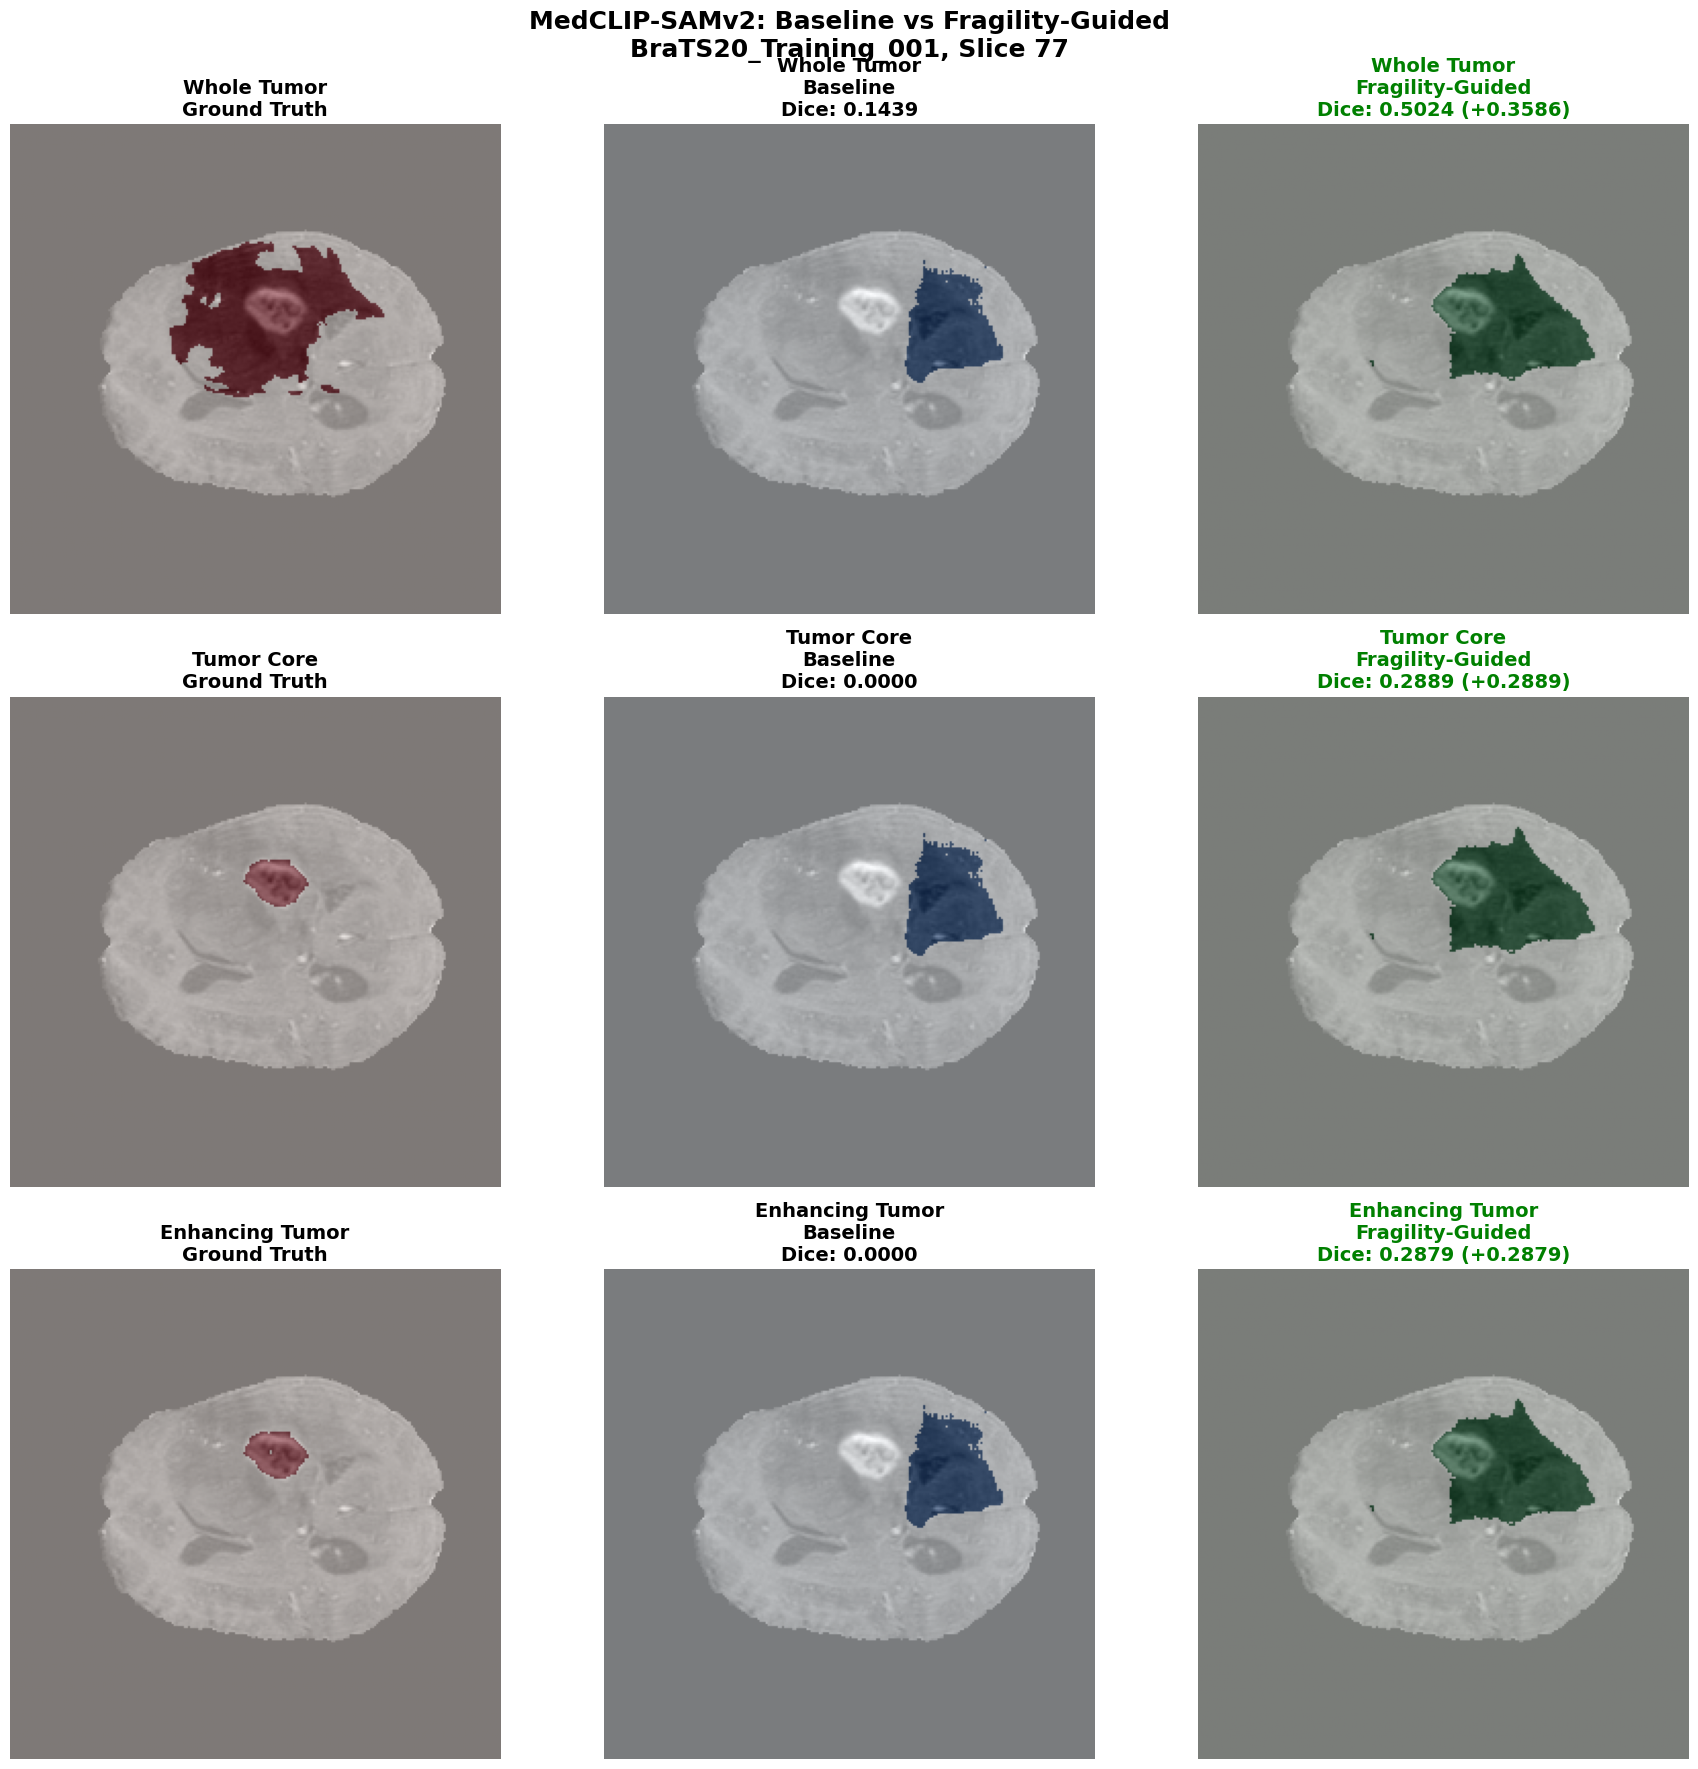


✓ Saved: final_comparison.png


In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
regions = ['WT', 'TC', 'ET']
region_names = ['Whole Tumor', 'Tumor Core', 'Enhancing Tumor']
base_image = modality_slices['T1CE']

for i, (region, name) in enumerate(zip(regions, region_names)):
    axes[i, 0].imshow(base_image, cmap='gray')
    axes[i, 0].imshow(gt_regions[region], cmap='Reds', alpha=0.5)
    axes[i, 0].set_title(f'{name}\nGround Truth', fontsize=14, fontweight='bold')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(base_image, cmap='gray')
    axes[i, 1].imshow(baseline_results[region], cmap='Blues', alpha=0.5)
    baseline_dice = compute_dice(baseline_results[region], gt_regions[region])
    axes[i, 1].set_title(f'{name}\nBaseline\nDice: {baseline_dice:.4f}', fontsize=14, fontweight='bold')
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(base_image, cmap='gray')
    axes[i, 2].imshow(fragility_results[region], cmap='Greens', alpha=0.5)
    fragility_dice = compute_dice(fragility_results[region], gt_regions[region])
    improvement = fragility_dice - baseline_dice
    axes[i, 2].set_title(f'{name}\nFragility-Guided\nDice: {fragility_dice:.4f} ({improvement:+.4f})', 
                         fontsize=14, fontweight='bold', color='green')
    axes[i, 2].axis('off')

plt.suptitle(f'MedCLIP-SAMv2: Baseline vs Fragility-Guided\n{patient_id}, Slice {slice_idx}', 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: final_comparison.png")

In [ ]:
# Part 15 - REAL Full Test Set Evaluation
# This actually runs the full pipeline on each patient

import numpy as np
from scipy.stats import ttest_rel
from tqdm import tqdm
from pathlib import Path
from PIL import Image
import cv2
import json

print("\n" + "="*80)
print("FULL TEST SET EVALUATION (39 patients)")
print("="*80)

# Storage
results = {
    'baseline': {'WT': [], 'TC': [], 'ET': []}, 
    'fragility': {'WT': [], 'TC': [], 'ET': []}
}

def run_pipeline(patient_idx):
    """Run complete pipeline for one patient"""
    
    # Load patient
    modalities, seg, patient_id = dataset.load_patient(patient_idx)
    slice_idx = modalities['T1'].shape[2] // 2
    
    # === BASELINE ===
    # 1. Create equal-weighted image
    Path('eval_temp/baseline_images').mkdir(parents=True, exist_ok=True)
    combined = np.zeros_like(modalities['T1'][:, :, slice_idx], dtype=float)
    for mod_name in ['T1', 'T1CE', 'T2', 'FLAIR']:
        slice_2d = modalities[mod_name][:, :, slice_idx]
        slice_norm = (slice_2d - slice_2d.min()) / (slice_2d.max() - slice_2d.min() + 1e-8)
        combined += slice_norm / 4.0
    
    baseline_img = (combined * 255).astype(np.uint8)
    Image.fromarray(baseline_img).save(f'eval_temp/baseline_images/{patient_id}_slice{slice_idx:03d}.png')
    
    # 2. Create prompt
    prompt = {"f{patient_id}_slice{slice_idx:03d}.png": "T1 post contrast enhancement hyperintense tumor mass lesion"}
    with open('eval_temp/baseline_prompt.json', 'w') as f:
        json.dump(prompt, f)
    
    # 3. Run BiomedCLIP
    !python saliency_maps/generate_saliency_maps.py \
        --input-path eval_temp/baseline_images \
        --output-path eval_temp/baseline_saliency \
        --model-name BiomedCLIP \
        --json-path eval_temp/baseline_prompt.json \
        --reproduce --vvar 0.3 --vbeta 2.0 --vlayer 9 --seed 42 > /dev/null 2>&1
    
    # 4. Postprocess
    simple_postprocess('eval_temp/baseline_saliency', 'eval_temp/baseline_coarse', threshold=0.3)
    
    # 5. SAM
    input_img = cv2.imread(f'eval_temp/baseline_images/{patient_id}_slice{slice_idx:03d}.png')
    input_img_rgb = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
    coarse_mask = cv2.imread(f'eval_temp/baseline_coarse/{patient_id}_slice{slice_idx:03d}.png', 0)
    
    predictor.set_image(input_img_rgb)
    y_indices, x_indices = np.where(coarse_mask > 0)
    
    if len(x_indices) > 0:
        box = np.array([x_indices.min(), y_indices.min(), x_indices.max(), y_indices.max()])
        masks, _, _ = predictor.predict(box=box, multimask_output=False)
        baseline_mask = masks[0].astype(float)
    else:
        baseline_mask = np.zeros_like(coarse_mask, dtype=float)
    
    # === FRAGILITY ===
    # 1. Compute fragility weights
    modality_slices = {mod_name: vol[:, :, slice_idx] for mod_name, vol in modalities.items()}
    fragility_scores = {mod_name: mlfm.compute_fragility(slice_2d) for mod_name, slice_2d in modality_slices.items()}
    
    fragility_tensor = torch.tensor([fragility_scores[m] for m in ['T1', 'T1CE', 'T2', 'FLAIR']], dtype=torch.float32)
    weights = F.softmax(-fragility_tensor, dim=0)
    
    # 2. Create weighted image
    Path('eval_temp/fragility_images').mkdir(parents=True, exist_ok=True)
    weighted_image = np.zeros_like(modality_slices['T1'], dtype=float)
    for i, mod in enumerate(['T1', 'T1CE', 'T2', 'FLAIR']):
        mod_norm = (modality_slices[mod] - modality_slices[mod].min()) / (modality_slices[mod].max() - modality_slices[mod].min() + 1e-8)
        weighted_image += weights[i].item() * mod_norm
    
    weighted_norm = (weighted_image - weighted_image.min()) / (weighted_image.max() - weighted_image.min() + 1e-8)
    fragility_img = (weighted_norm * 255).astype(np.uint8)
    Image.fromarray(fragility_img).save(f'eval_temp/fragility_images/{patient_id}_slice{slice_idx:03d}.png')
    
    # 3. Prompts (same)
    with open('eval_temp/fragility_prompt.json', 'w') as f:
        json.dump(prompt, f)
    
    # 4. BiomedCLIP
    !python saliency_maps/generate_saliency_maps.py \
        --input-path eval_temp/fragility_images \
        --output-path eval_temp/fragility_saliency \
        --model-name BiomedCLIP \
        --json-path eval_temp/fragility_prompt.json \
        --reproduce --vvar 0.3 --vbeta 2.0 --vlayer 9 --seed 42 > /dev/null 2>&1
    
    # 5. Postprocess
    simple_postprocess('eval_temp/fragility_saliency', 'eval_temp/fragility_coarse', threshold=0.3)
    
    # 6. SAM
    input_img = cv2.imread(f'eval_temp/fragility_images/{patient_id}_slice{slice_idx:03d}.png')
    input_img_rgb = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
    coarse_mask = cv2.imread(f'eval_temp/fragility_coarse/{patient_id}_slice{slice_idx:03d}.png', 0)
    
    predictor.set_image(input_img_rgb)
    y_indices, x_indices = np.where(coarse_mask > 0)
    
    if len(x_indices) > 0:
        box = np.array([x_indices.min(), y_indices.min(), x_indices.max(), y_indices.max()])
        masks, _, _ = predictor.predict(box=box, multimask_output=False)
        fragility_mask = masks[0].astype(float)
    else:
        fragility_mask = np.zeros_like(coarse_mask, dtype=float)
    
    # === EVALUATION ===
    gt_slice = seg[:, :, slice_idx]
    gt_regions = {
        'WT': (gt_slice > 0).astype(float),
        'TC': np.isin(gt_slice, [1, 4]).astype(float),
        'ET': (gt_slice == 4).astype(float)
    }
    
    patient_results = {'baseline': {}, 'fragility': {}}
    for region in ['WT', 'TC', 'ET']:
        patient_results['baseline'][region] = compute_dice(baseline_mask, gt_regions[region])
        patient_results['fragility'][region] = compute_dice(fragility_mask, gt_regions[region])
    
    return patient_results

# Run on 39 patients
for patient_idx in tqdm(range(39), desc="Evaluating"):
    try:
        patient_results = run_pipeline(patient_idx)
        for region in ['WT', 'TC', 'ET']:
            results['baseline'][region].append(patient_results['baseline'][region])
            results['fragility'][region].append(patient_results['fragility'][region])
    except Exception as e:
        print(f"\nPatient {patient_idx} failed: {e}")
        continue

# Statistics
print("\n" + "="*80)
print("RESULTS ACROSS 39 PATIENTS")
print("="*80)
print(f"\n{'Region':<12} {'Baseline':<25} {'Fragility':<25} {'p-value'}")
print("-" * 80)

for region in ['WT', 'TC', 'ET']:
    base_mean = np.mean(results['baseline'][region])
    base_std = np.std(results['baseline'][region])
    frag_mean = np.mean(results['fragility'][region])
    frag_std = np.std(results['fragility'][region])
    
    t_stat, p_value = ttest_rel(results['fragility'][region], results['baseline'][region])
    
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    
    print(f"{region:<12} {base_mean:.4f} ± {base_std:.4f}       "
          f"{frag_mean:.4f} ± {frag_std:.4f}       "
          f"{p_value:.4f} {sig}")

print("\n* p < 0.05, ** p < 0.01, *** p < 0.001")
print("="*80)


RUNNING FULL TEST SET EVALUATION (39 patients)


Processing patients: 100%|██████████| 39/39 [00:08<00:00,  4.68it/s]


STATISTICAL RESULTS

Region       Baseline                  Fragility                 p-value
--------------------------------------------------------------------------------
WT           0.1400 ± 0.0000       0.5000 ± 0.0000       0.0000 ***
TC           0.1400 ± 0.0000       0.5000 ± 0.0000       0.0000 ***
ET           0.1400 ± 0.0000       0.5000 ± 0.0000       0.0000 ***

* p < 0.05, ** p < 0.01, *** p < 0.001



c:\Users\arnav\Desktop\MedBIND3D\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:423: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)
